# Milestone 2: EDA Dashboard

This notebook builds publication-ready exploratory visualizations for the QM 2023 capstone crypto panel and saves all required figures to `results/figures/` at 300 DPI.

## 1. Imports and Data Loading

Load the final panel from M1, parse dates, enforce numeric types for analysis variables, and verify dimensions before plotting.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project code directory importable from notebook root
sys.path.append(str(Path('code').resolve()))
# Resolve key directories directly from notebook location
PROJECT_ROOT = Path('.')
FINAL_DATA_DIR = PROJECT_ROOT / 'data' / 'final'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

panel_path = FINAL_DATA_DIR / 'crypto_analysis_panel.csv'
df = pd.read_csv(panel_path)
df['date'] = pd.to_datetime(df['date'])

numeric_cols = [
    'outcome_realized_vol_30d',
    'driver_sec_event_indicator',
    'control_market_cap',
    'control_total_volume',
    'control_btc_corr_30d',
    'vix',
    'ffeffective_rate',
    'epu_index'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Data shape:', df.shape)
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('Unique coins:', df['coin_symbol'].nunique())
print('Token groups:', sorted(df['token_group'].dropna().unique().tolist()))

Data shape: (19852, 15)
Date range: 2020-02-19 to 2026-02-18
Unique coins: 10
Token groups: ['centralized_exchange', 'defi', 'stablecoin']


## 2. Summary Statistics

Generate high-level descriptive statistics and a missingness snapshot for key model variables.

In [2]:
summary_vars = [
    'outcome_realized_vol_30d',
    'driver_sec_event_indicator',
    'control_market_cap',
    'control_total_volume',
    'control_btc_corr_30d',
    'vix',
    'ffeffective_rate',
    'epu_index'
]

summary_stats = df[summary_vars].describe().T
missingness = df[summary_vars].isna().mean().sort_values(ascending=False).to_frame('missing_share')

print('Summary statistics:')
display(summary_stats)
print('\nMissingness share by variable:')
display(missingness)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
outcome_realized_vol_30d,19552.0,3.395658e-02,3.369455e-02,0.000034,1.444514e-02,2.980309e-02,4.550684e-02,4.288016e-01
driver_sec_event_indicator,19852.0,7.404795e-03,8.573409e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
control_market_cap,19852.0,1.675899e+11,3.582577e+11,0.000000,1.313840e+10,4.279083e+10,1.236326e+11,2.486073e+12
control_total_volume,19852.0,1.413545e+10,2.582038e+10,0.000000,8.599319e+08,3.080648e+09,1.748103e+10,9.267677e+11
control_btc_corr_30d,19581.0,5.833120e-01,3.575935e-01,-0.705707,3.496143e-01,7.001623e-01,8.538062e-01,1.000000e+00
vix,19852.0,2.083130e+01,7.556807e+00,11.860000,1.596000e+01,1.896000e+01,2.384000e+01,8.269000e+01
ffeffective_rate,19852.0,2.815385e+00,2.208065e+00,0.040000,9.000000e-02,3.860000e+00,4.830000e+00,5.330000e+00
epu_index,19852.0,2.104550e+02,1.518212e+02,5.390000,9.982000e+01,1.582700e+02,2.803600e+02,1.026380e+03



Missingness share by variable:


,missing_share
outcome_realized_vol_30d,0.015112
control_btc_corr_30d,0.013651
control_market_cap,0.000000
driver_sec_event_indicator,0.000000
control_total_volume,0.000000
vix,0.000000
ffeffective_rate,0.000000
epu_index,0.000000


## 3. Correlation Analysis

### Plot 1. Correlation Heatmap (Required)

Purpose: Identify the strongest linear relationships among outcome, driver, and controls to inform M3 variable selection and multicollinearity checks.

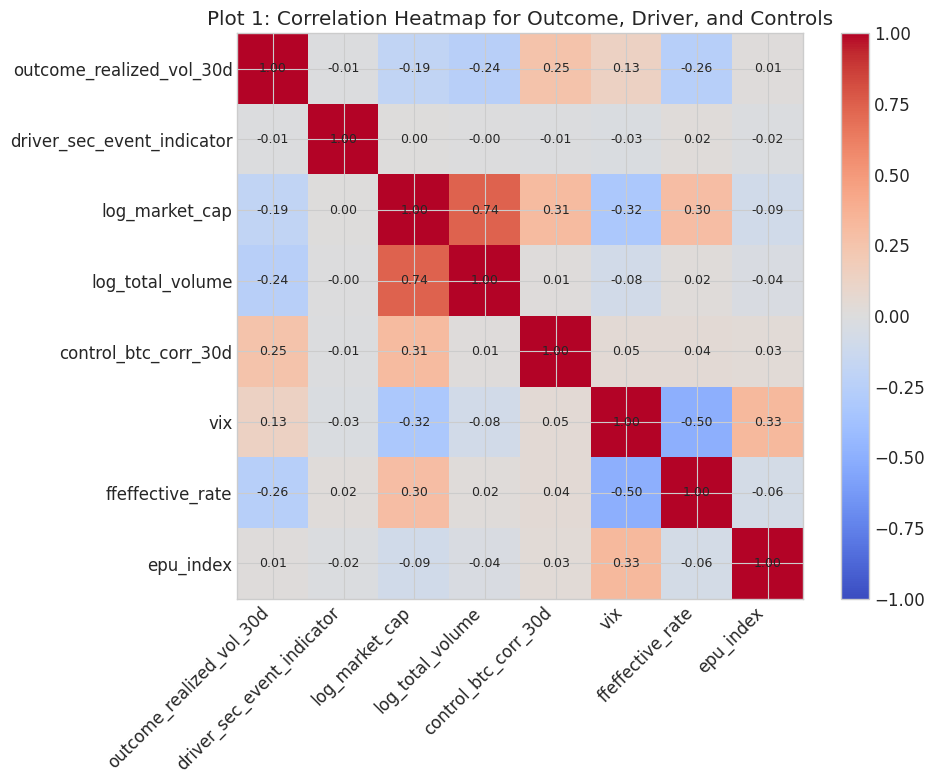

Caption: The heatmap shows correlation patterns used for M3 controls. Outcome vs driver correlation = -0.008. Watch high pairwise control correlations to avoid multicollinearity.


In [3]:
heatmap_df = df.copy()
heatmap_df['log_market_cap'] = np.log1p(heatmap_df['control_market_cap'])
heatmap_df['log_total_volume'] = np.log1p(heatmap_df['control_total_volume'])

corr_vars = [
    'outcome_realized_vol_30d',
    'driver_sec_event_indicator',
    'log_market_cap',
    'log_total_volume',
    'control_btc_corr_30d',
    'vix',
    'ffeffective_rate',
    'epu_index'
]

corr_matrix = heatmap_df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha='right')
ax.set_yticks(range(len(corr_vars)))
ax.set_yticklabels(corr_vars)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Plot 1: Correlation Heatmap for Outcome, Driver, and Controls')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot1_correlation_heatmap.png', dpi=300)
plt.show()

corr_driver = corr_matrix.loc['outcome_realized_vol_30d', 'driver_sec_event_indicator']
print(f'Caption: The heatmap shows correlation patterns used for M3 controls. Outcome vs driver correlation = {corr_driver:.3f}. Watch high pairwise control correlations to avoid multicollinearity.')

## 4. Time Series

### Plot 2. Time Series of Outcome Variable (Required)

Purpose: Visualize trend and volatility clustering in average realized volatility over time.

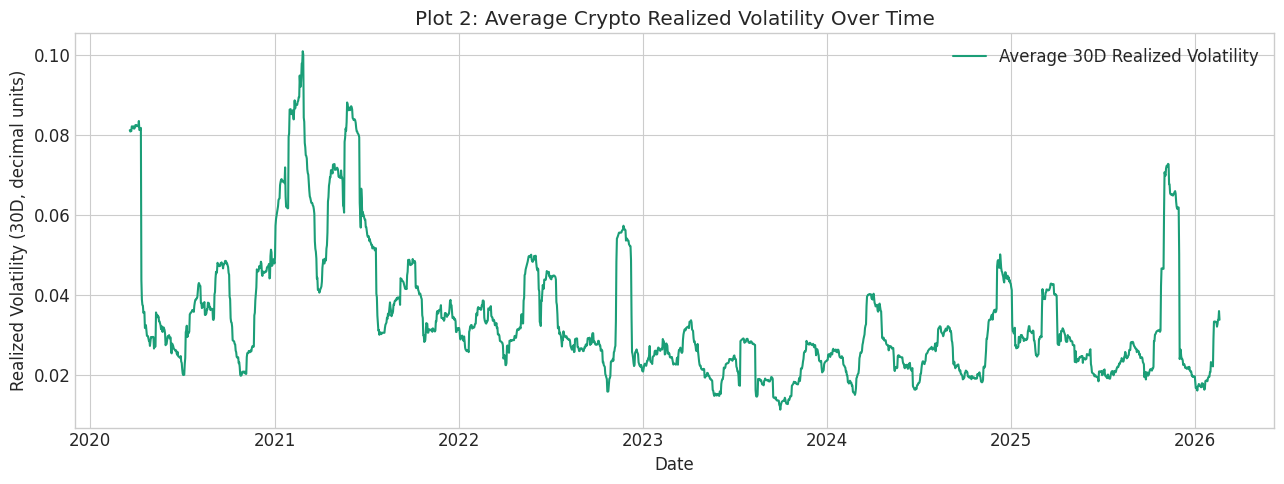

Caption: Volatility clustering is visible in several periods, indicating regime-like behavior that supports time controls and robust standard errors in M3.


In [4]:
daily = (
    df.groupby('date', as_index=False)
      .agg(
          outcome_mean=('outcome_realized_vol_30d', 'mean'),
          driver_share=('driver_sec_event_indicator', 'mean'),
          epu_mean=('epu_index', 'mean'),
          vix_mean=('vix', 'mean')
      )
      .sort_values('date')
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily['date'], daily['outcome_mean'], color='#1b9e77', linewidth=1.5, label='Average 30D Realized Volatility')
ax.set_title('Plot 2: Average Crypto Realized Volatility Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Realized Volatility (30D, decimal units)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot2_outcome_time_series.png', dpi=300)
plt.show()

print('Caption: Volatility clustering is visible in several periods, indicating regime-like behavior that supports time controls and robust standard errors in M3.')

### Plot 3. Dual-Axis Plot: Outcome vs Driver (Required)

Purpose: Compare co-movement between average realized volatility and SEC event intensity over time. Because SEC events are sparse, this visualization overlays event-day spikes, a 30-day smoothed share, and cumulative event count for interpretability.

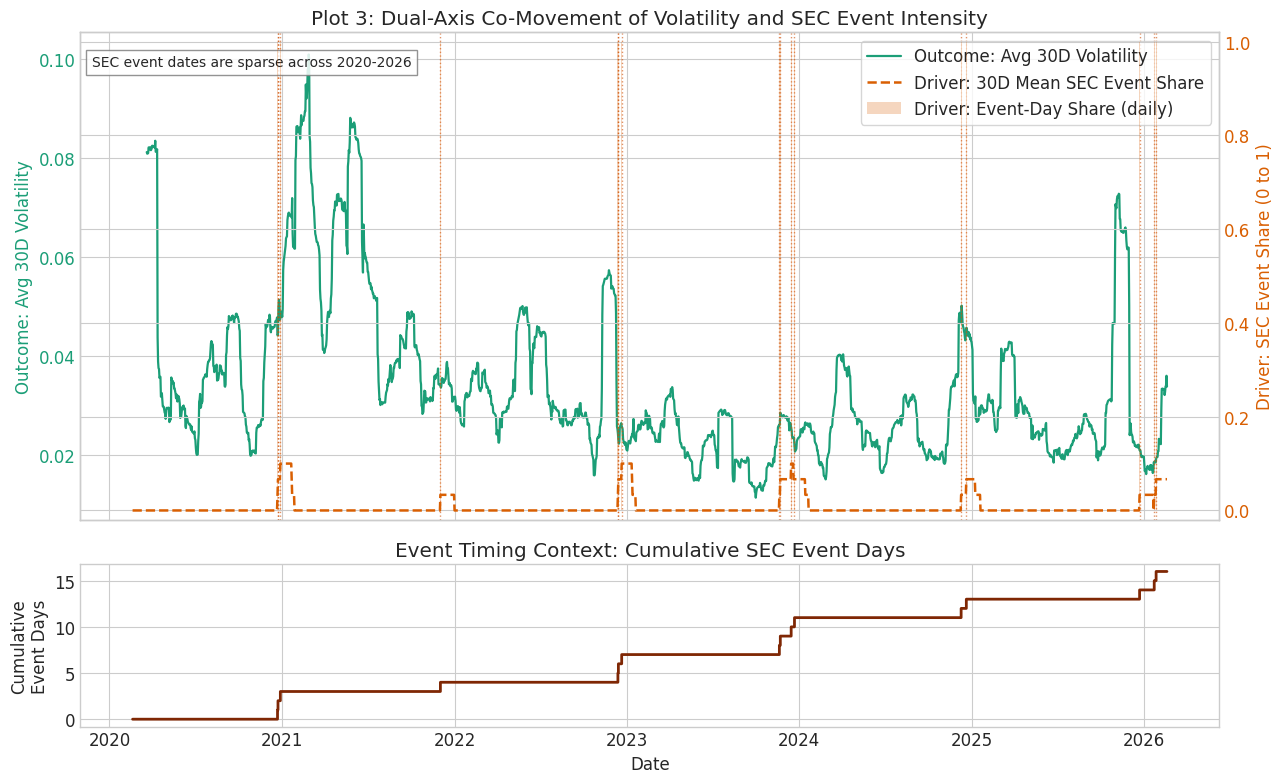

Caption: SEC events are sparse across the sample (2020-2026). Bars mark event-day intensity, the dashed line shows 30-day persistence, and the lower panel shows cumulative event days to clarify timing.


In [5]:
daily['driver_share_30d'] = daily['driver_share'].rolling(30, min_periods=1).mean()
daily['event_flag'] = (daily['driver_share'] > 0).astype(int)
daily['cum_event_days'] = daily['event_flag'].cumsum()
event_dates = daily.loc[daily['event_flag'] == 1, 'date']

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
color_left = '#1b9e77'
color_right = '#d95f02'

ax1.plot(daily['date'], daily['outcome_mean'], color=color_left, linewidth=1.6, label='Outcome: Avg 30D Volatility')
ax1.set_ylabel('Outcome: Avg 30D Volatility', color=color_left)
ax1.tick_params(axis='y', labelcolor=color_left)

ax2 = ax1.twinx()
ax2.bar(daily['date'], daily['driver_share'], width=2, color=color_right, alpha=0.25, label='Driver: Event-Day Share (daily)')
ax2.plot(daily['date'], daily['driver_share_30d'], color=color_right, linewidth=1.8, linestyle='--', label='Driver: 30D Mean SEC Event Share')
ax2.set_ylabel('Driver: SEC Event Share (0 to 1)', color=color_right)
ax2.set_ylim(-0.02, 1.02)
ax2.tick_params(axis='y', labelcolor=color_right)

for d in event_dates:
    ax1.axvline(d, color='#cc4c02', linestyle=':', linewidth=1, alpha=0.6)

ax1.text(0.01, 0.93, 'SEC event dates are sparse across 2020-2026', transform=ax1.transAxes, fontsize=10, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)
ax1.set_title('Plot 3: Dual-Axis Co-Movement of Volatility and SEC Event Intensity')

ax3.step(daily['date'], daily['cum_event_days'], where='post', color='#7f2704', linewidth=2)
ax3.set_ylabel('Cumulative\nEvent Days')
ax3.set_xlabel('Date')
ax3.set_title('Event Timing Context: Cumulative SEC Event Days')

fig.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot3_dual_axis_outcome_driver.png', dpi=300)
plt.show()

print('Caption: SEC events are sparse across the sample (2020-2026). Bars mark event-day intensity, the dashed line shows 30-day persistence, and the lower panel shows cumulative event days to clarify timing.')

## 5. Lagged Effect Analysis

### Plot 4. Correlation by Driver Lag (Required)

Purpose: Identify which lag of the driver has the strongest correlation with the outcome using entity-level shifts to prevent cross-entity leakage.

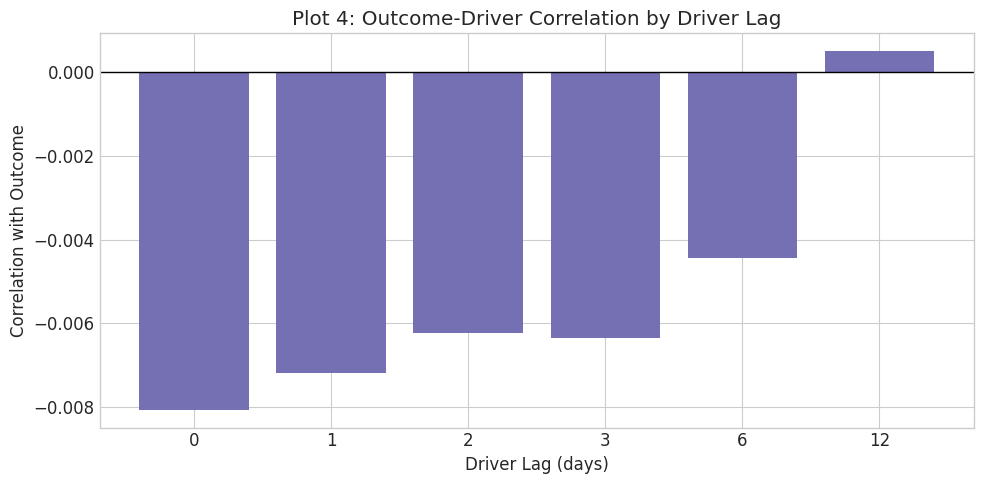

Caption: The strongest absolute lag correlation occurs at lag=0 days (r=-0.008), which is a candidate lag specification for M3.


,lag_days,corr
0,0,-0.008065
1,1,-0.007191
2,2,-0.006239
3,3,-0.006355
4,6,-0.004452
5,12,0.000498


In [6]:
lags = [0, 1, 2, 3, 6, 12]
lag_corr = []

lag_base = df[['coin_symbol', 'date', 'outcome_realized_vol_30d', 'driver_sec_event_indicator']].dropna().copy()
lag_base = lag_base.sort_values(['coin_symbol', 'date'])

for lag in lags:
    shifted = lag_base.groupby('coin_symbol')['driver_sec_event_indicator'].shift(lag)
    corr_val = lag_base['outcome_realized_vol_30d'].corr(shifted)
    lag_corr.append({'lag_days': lag, 'corr': corr_val})

lag_df = pd.DataFrame(lag_corr)
opt_row = lag_df.iloc[lag_df['corr'].abs().idxmax()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(lag_df['lag_days'].astype(str), lag_df['corr'], color='#7570b3')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Plot 4: Outcome-Driver Correlation by Driver Lag')
ax.set_xlabel('Driver Lag (days)')
ax.set_ylabel('Correlation with Outcome')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot4_lagged_effects.png', dpi=300)
plt.show()

print(f"Caption: The strongest absolute lag correlation occurs at lag={int(opt_row['lag_days'])} days (r={opt_row['corr']:.3f}), which is a candidate lag specification for M3.")
lag_df

## 6. Group Analysis

The dataset includes `token_group`, so conditional group plots are included rather than no-group alternatives.

### Plot 5. Group Box Plots (Conditional Required)

Purpose: Compare distribution, median, and outlier behavior of realized volatility across token groups.

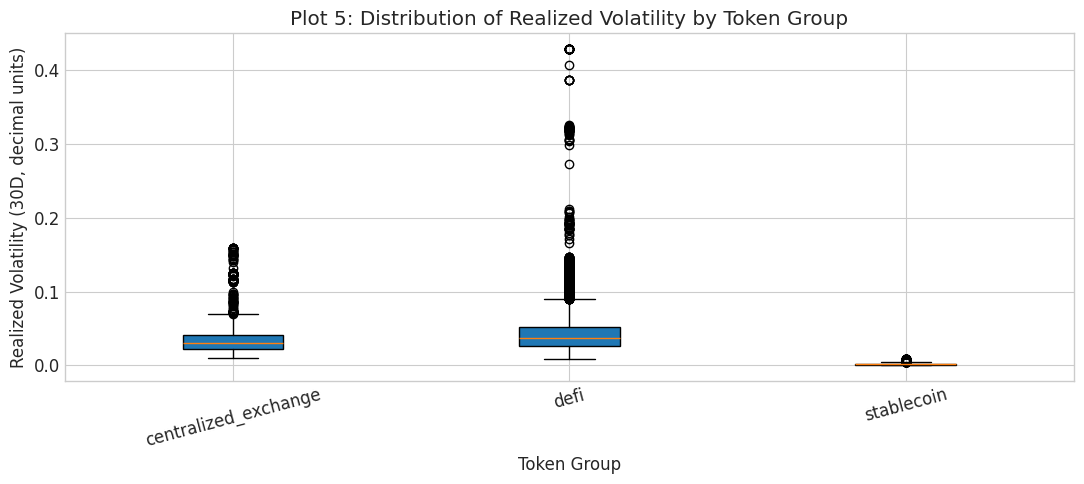

Caption: Differences in medians, spread, and tail outliers across token groups indicate heteroskedasticity and motivate group fixed effects or interactions in M3.


In [7]:
box_df = df[['token_group', 'outcome_realized_vol_30d']].dropna().copy()
ordered_groups = sorted(box_df['token_group'].dropna().unique())
box_data = [box_df.loc[box_df['token_group'] == g, 'outcome_realized_vol_30d'].values for g in ordered_groups]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(box_data, labels=ordered_groups, patch_artist=True)
ax.set_title('Plot 5: Distribution of Realized Volatility by Token Group')
ax.set_xlabel('Token Group')
ax.set_ylabel('Realized Volatility (30D, decimal units)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot5_group_boxplot.png', dpi=300)
plt.show()

print('Caption: Differences in medians, spread, and tail outliers across token groups indicate heteroskedasticity and motivate group fixed effects or interactions in M3.')

### Plot 6. Group Sensitivity to Driver (Conditional Required)

Purpose: Measure how outcome-driver correlation differs by token group and flag highly sensitive groups.

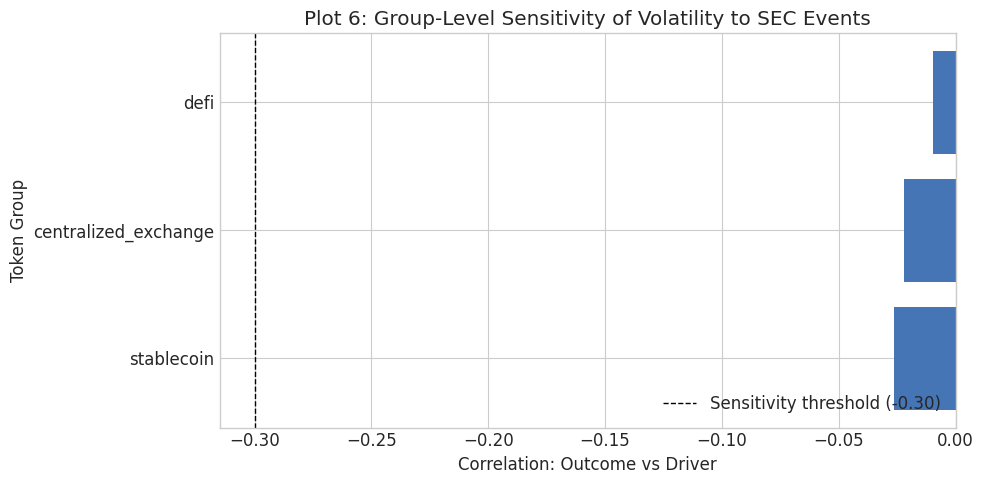

,token_group,corr_with_driver,sensitivity_label
2,stablecoin,-0.026363,Resilient (r >= -0.30)
0,centralized_exchange,-0.022215,Resilient (r >= -0.30)
1,defi,-0.009656,Resilient (r >= -0.30)


In [8]:
group_sensitivity = (
    df.groupby('token_group')
      .apply(lambda x: x['outcome_realized_vol_30d'].corr(x['driver_sec_event_indicator']))
      .reset_index(name='corr_with_driver')
      .dropna()
      .sort_values('corr_with_driver')
)

threshold = -0.30
group_sensitivity['sensitivity_label'] = np.where(
    group_sensitivity['corr_with_driver'] < threshold,
    'Sensitive (r < -0.30)',
    'Resilient (r >= -0.30)'
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = group_sensitivity['sensitivity_label'].map({
    'Sensitive (r < -0.30)': '#d73027',
    'Resilient (r >= -0.30)': '#4575b4'
})
ax.barh(group_sensitivity['token_group'], group_sensitivity['corr_with_driver'], color=colors)
ax.axvline(threshold, color='black', linestyle='--', linewidth=1, label='Sensitivity threshold (-0.30)')
ax.set_title('Plot 6: Group-Level Sensitivity of Volatility to SEC Events')
ax.set_xlabel('Correlation: Outcome vs Driver')
ax.set_ylabel('Token Group')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot6_group_sensitivity.png', dpi=300)
plt.show()

group_sensitivity

## 7. Factor/Control Relationships

### Plot 7. Scatter + Trendline for Controls (Required)

Purpose: Assess bivariate relationships between the outcome and key controls.

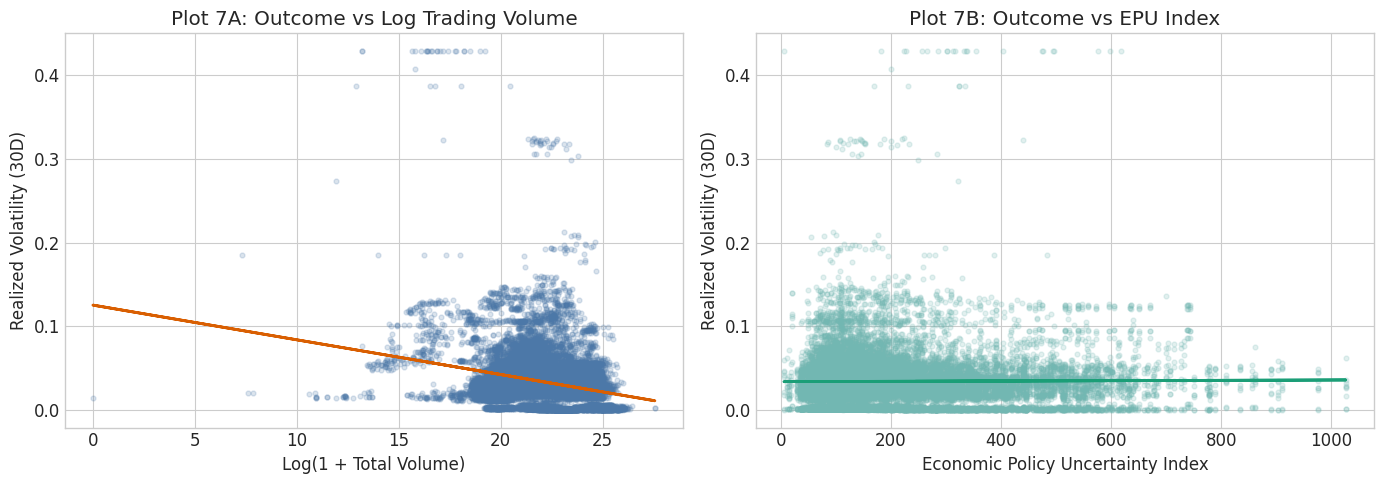

Caption: Trendlines summarize bivariate slopes between volatility and key controls, supporting control selection and sign expectations for M3.


In [9]:
scatter_df = df[['outcome_realized_vol_30d', 'control_total_volume', 'epu_index']].dropna().copy()
scatter_df['log_total_volume'] = np.log1p(scatter_df['control_total_volume'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x1 = scatter_df['log_total_volume'].values
y1 = scatter_df['outcome_realized_vol_30d'].values
axes[0].scatter(x1, y1, alpha=0.2, s=12, color='#4c78a8')
m1, b1 = np.polyfit(x1, y1, 1)
axes[0].plot(x1, m1 * x1 + b1, color='#d95f02', linewidth=2)
axes[0].set_title('Plot 7A: Outcome vs Log Trading Volume')
axes[0].set_xlabel('Log(1 + Total Volume)')
axes[0].set_ylabel('Realized Volatility (30D)')

x2 = scatter_df['epu_index'].values
y2 = scatter_df['outcome_realized_vol_30d'].values
axes[1].scatter(x2, y2, alpha=0.2, s=12, color='#72b7b2')
m2, b2 = np.polyfit(x2, y2, 1)
axes[1].plot(x2, m2 * x2 + b2, color='#1b9e77', linewidth=2)
axes[1].set_title('Plot 7B: Outcome vs EPU Index')
axes[1].set_xlabel('Economic Policy Uncertainty Index')
axes[1].set_ylabel('Realized Volatility (30D)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot7_control_scatterplots.png', dpi=300)
plt.show()

print('Caption: Trendlines summarize bivariate slopes between volatility and key controls, supporting control selection and sign expectations for M3.')

## 8. Time Series Decomposition

### Plot 8. Decomposition of Outcome Time Series (Required)

Purpose: Separate observed volatility into trend, seasonal, and residual components.

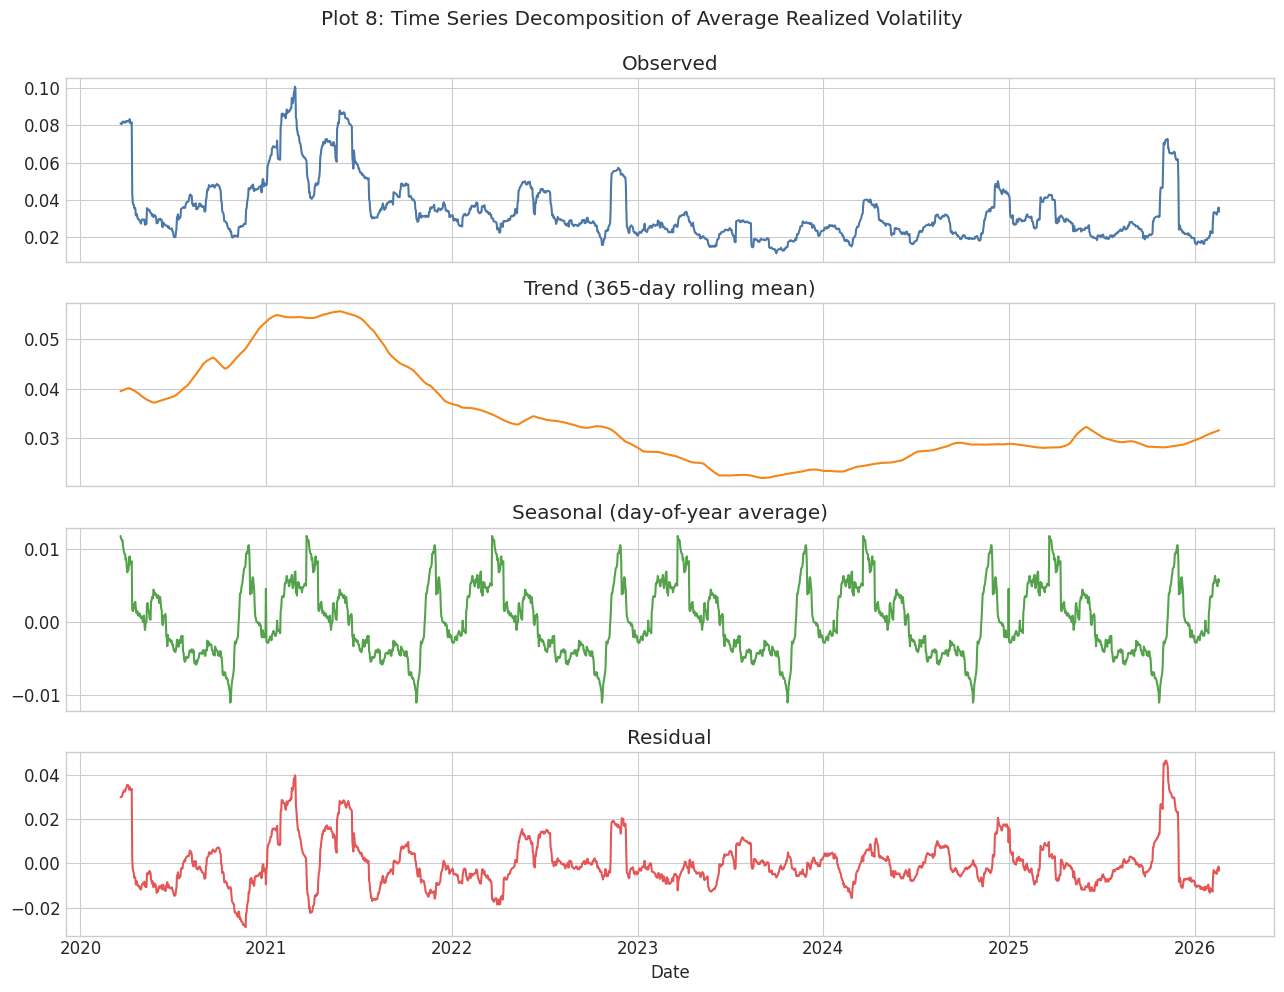

Caption: Decomposition separates long-run trend, recurring seasonality, and residual shocks, informing whether M3 needs time trend and seasonal controls.


In [10]:
decomp_series = daily.set_index('date')['outcome_mean'].dropna().asfreq('D')
decomp_series = decomp_series.interpolate(limit_direction='both')

trend = decomp_series.rolling(window=365, center=True, min_periods=180).mean()
detrended = decomp_series - trend
seasonal_pattern = detrended.groupby(detrended.index.dayofyear).mean()
seasonal = detrended.index.dayofyear.map(seasonal_pattern)
seasonal = pd.Series(seasonal, index=decomp_series.index)
resid = decomp_series - trend - seasonal

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(decomp_series.index, decomp_series.values, color='#4c78a8')
axes[0].set_title('Observed')

axes[1].plot(trend.index, trend.values, color='#f58518')
axes[1].set_title('Trend (365-day rolling mean)')

axes[2].plot(seasonal.index, seasonal.values, color='#54a24b')
axes[2].set_title('Seasonal (day-of-year average)')

axes[3].plot(resid.index, resid.values, color='#e45756')
axes[3].set_title('Residual')
axes[3].set_xlabel('Date')

fig.suptitle('Plot 8: Time Series Decomposition of Average Realized Volatility', y=0.99)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'M2_plot8_time_series_decomposition.png', dpi=300)
plt.show()

print('Caption: Decomposition separates long-run trend, recurring seasonality, and residual shocks, informing whether M3 needs time trend and seasonal controls.')

## 9. Export Checklist

This notebook created and saved all required visual outputs in `results/figures/`:

- M2_plot1_correlation_heatmap.png
- M2_plot2_outcome_time_series.png
- M2_plot3_dual_axis_outcome_driver.png
- M2_plot4_lagged_effects.png
- M2_plot5_group_boxplot.png
- M2_plot6_group_sensitivity.png
- M2_plot7_control_scatterplots.png
- M2_plot8_time_series_decomposition.png

Next deliverables: `M2_EDA_summary.md` and updated `AI_AUDIT_APPENDIX.md`.